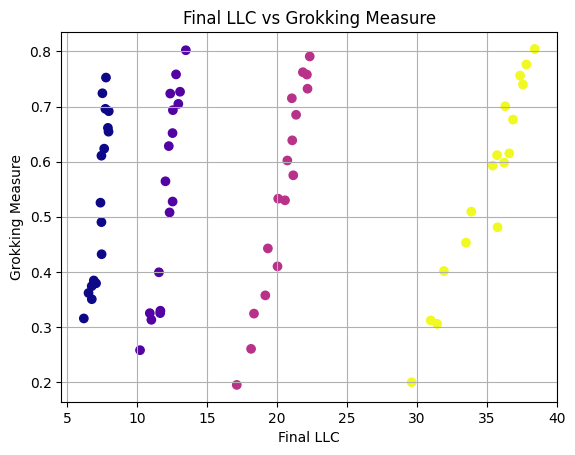

In [37]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from utils.metrics import grokking_test3
# loop over files in ./results/sweep_batch_lr_wd
llc_list = []
grokking_list = []
batch_sizes = []
for folder in os.listdir('./results/sweep_batch_lr_wd'):
    folder_path = os.path.join('./results/sweep_batch_lr_wd', folder)
    params = pd.read_csv(os.path.join(folder_path, 'params.csv'))
    results = pd.read_csv(os.path.join(folder_path, 'loss_data.csv'))
    grokking = grokking_test3(results['train_acc'].values, results['val_acc'].values)
    weight_decay = params['weight_decay'].values[0]
    if grokking > 0 and weight_decay != 0.0005:
        llc_list.append(results['llc'].values[-1])
        grokking_list.append(grokking)
        batch_sizes.append(params['batch_size'].values[0])

plt.scatter(llc_list, grokking_list, c= batch_sizes, cmap= "plasma")
plt.xlabel('Final LLC')
plt.ylabel('Grokking Measure')
plt.title('Final LLC vs Grokking Measure')
plt.grid()


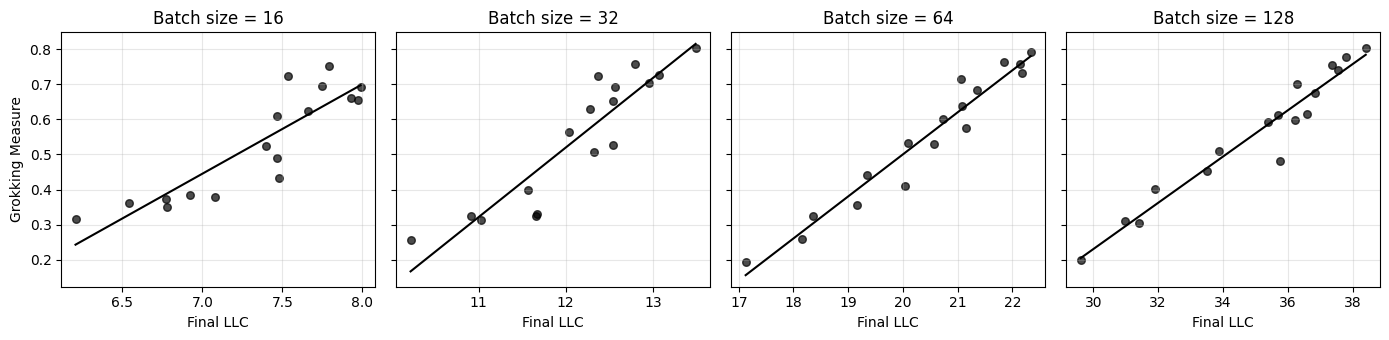

In [39]:
import numpy as np
import matplotlib.pyplot as plt

batch_sizes_unique = sorted(set(batch_sizes))

fig, axes = plt.subplots(
    1,4,
    figsize=(14, 3.5),
    sharey=True
)

for ax, bs in zip(axes, batch_sizes_unique):
    xs = np.array([x for x, b in zip(llc_list, batch_sizes) if b == bs])
    ys = np.array([y for y, b in zip(grokking_list, batch_sizes) if b == bs])

    ax.scatter(
        xs, ys,
        color='black',
        alpha=0.7,
        s=30
    )

    if len(xs) >= 2:
        coeffs = np.polyfit(xs, ys, 1)
        x_line = np.linspace(xs.min(), xs.max(), 100)
        y_line = np.polyval(coeffs, x_line)
        ax.plot(
            x_line, y_line,
            color='black',
            linewidth=1.5
        )

    ax.set_title(f'Batch size = {bs}')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Grokking Measure')
for ax in axes:
    ax.set_xlabel('Final LLC')

plt.tight_layout()
plt.show()


In [ ]:
def linear_fit_and_plot(path = "./results/sweep_batch_lr_wd", 
                        enforced_params: dict = {'batch_size': [64], 'weight_decay': [0.00001, 0.000001, 0.00005, 0.00001, 0]},
                        x_axis = "llc",
                        y_axis = "grokking"):
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    from utils.metrics import grokking_test3
    import numpy as np
    
    # loop over files in path
    llc_list = []
    grokking_list = []
    max_llc = []
    p = []
    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)
        params = pd.read_csv(os.path.join(folder_path, 'params.csv'))
        results = pd.read_csv(os.path.join(folder_path, 'loss_data.csv'))
        grokking = grokking_test3(results['train_acc'].values, results['val_acc'].values)
        include = True
        for key, value in enforced_params.items():
            if params[key].values[0] not in value:
                    include = False
                    break
        if grokking > 0 and include:
            llc_list.append(results['llc'].values[-1])
            max_llc.append(np.max(results['llc'].values))
            grokking_list.append(grokking)
            p.append(params['p'].values[0])
    if x_axis == "llc":
        x = np.array(llc_list)
    elif x_axis == "max_llc":
        x =  np.array(max_llc)
    elif x_axis == "p":
        x =  np.array(p)
    if y_axis == "llc":
        y = np.array(llc_list)
    elif y_axis == "max_llc":
        y =  np.array(max_llc)
    elif y_axis == "grokking":
        y = np.array(grokking_list)
    poly = np.polyfit(x, y, 1, full = True)
    a, b = poly[0]
    r2 = 1 - (poly[1][0] / (len(y) * np.var(y)))
    print(f"Linear fit: y = {a:.4f}x + {b:.4f}, R² = {r2:.4f}")
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = a * x_line + b
    plt.plot(x_line, y_line, linewidth=1.3, alpha=0.5)
    plt.scatter(x, y)
    plt.legend([f"y = {a:.3f}x + {b:.3f}, R² = {r2:.3f}"])
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.grid()
    plt.show()

Linear fit: y = 0.1288x + -2.0981, R² = 0.9546


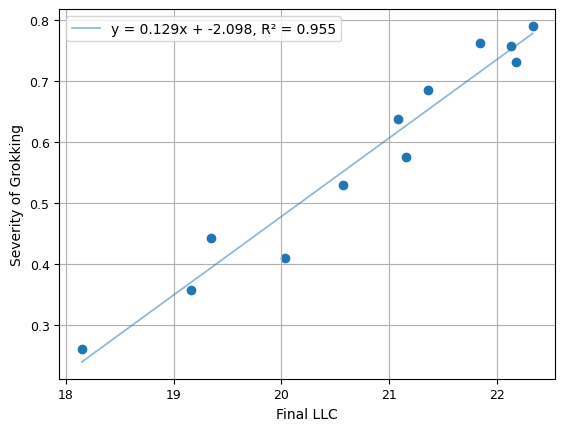

In [41]:
linear_fit_and_plot()

Linear fit: y = 0.0012x + -5.7457, R² = 0.7256


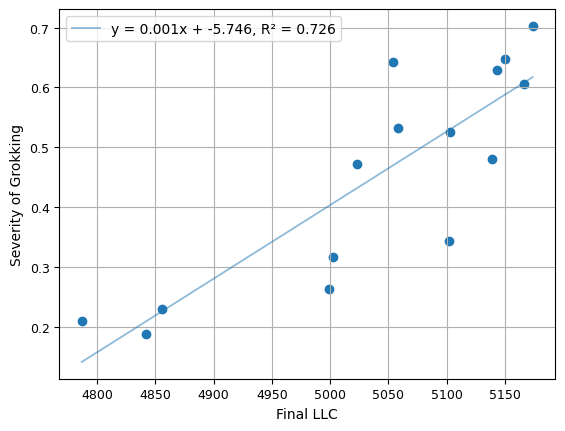

In [42]:
linear_fit_and_plot(path = "/home/se24/geom_phase_transitions/results/sweep_lr_wd_new", 
                    enforced_params = {})

Linear fit: y = -0.0081x + 8.7046, R² = 0.1028


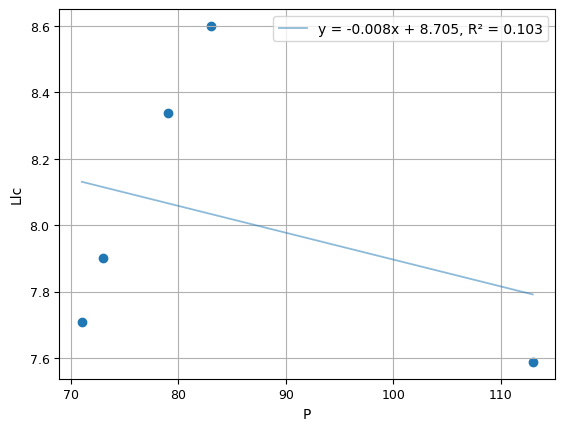

In [47]:
linear_fit_and_plot(path = "/home/se24/geom_phase_transitions/results/sweep_p_embed", 
                    enforced_params = {'embed_dim': [1024]},
                    x_axis = "p",
                    y_axis = "llc")

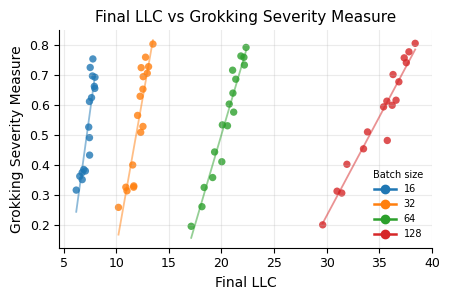

In [50]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from utils.metrics import grokking_test3

# -----------------------------
# Collect data
# -----------------------------
llc_list = []
grokking_list = []
batch_sizes = []

root = "./results/sweep_batch_lr_wd"
for folder in os.listdir(root):
    folder_path = os.path.join(root, folder)
    if not os.path.isdir(folder_path):
        continue

    params_path = os.path.join(folder_path, "params.csv")
    results_path = os.path.join(folder_path, "loss_data.csv")
    if not (os.path.exists(params_path) and os.path.exists(results_path)):
        continue

    params = pd.read_csv(params_path)
    results = pd.read_csv(results_path)

    grokking = grokking_test3(
        results["train_acc"].values,
        results["val_acc"].values
    )

    if grokking <= 0 or params["weight_decay"].values[0] == 0.0005:
        continue

    llc_list.append(results["llc"].values[-1])
    grokking_list.append(grokking)
    batch_sizes.append(int(params["batch_size"].values[0]))

llc = np.array(llc_list)
grok = np.array(grokking_list)
bs_arr = np.array(batch_sizes)

# -----------------------------
# Plot styling
# -----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig, ax = plt.subplots(figsize=(4.6, 3.1))  # slightly bigger, still ICML-safe

# Discrete colors (ICML-friendly)
colors = {
    16: "tab:blue",
    32: "tab:orange",
    64: "tab:green",
    128: "tab:red",
}

legend_handles = []

# -----------------------------
# Scatter + regression per batch
# -----------------------------
for bs in sorted(colors):
    mask = (bs_arr == bs)
    if not mask.any():
        continue

    x = llc[mask]
    y = grok[mask]
    color = colors[bs]

    ax.scatter(
        x, y,
        color=color,
        s=28,
        alpha=0.8,
        edgecolors="none",
        rasterized=True
    )

    if x.size >= 2:
        a, b = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = a * x_line + b
        ax.plot(x_line, y_line, color=color, linewidth=1.3, alpha=0.5)

    legend_handles.append(
        Line2D([0], [0], color=color, lw=1.8, marker="o", label=f"{bs}")
    )

# -----------------------------
# Axes & cosmetics
# -----------------------------
ax.set_xlabel("Final LLC")
ax.set_ylabel("Grokking Severity Measure")
ax.set_title("Final LLC vs Grokking Severity Measure")

ax.grid(True, alpha=0.25, linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    handles=legend_handles,
    title="Batch size",
    frameon=False,
    loc="best",
    fontsize=7,
    title_fontsize=7,
    handlelength=2.2
)

fig.tight_layout()
plt.show()


# Shapes of loss functions and llc


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from utils.metrics import grokking_test3
# loop over files in ./results/sweep_batch_lr_wd
llc_list = []
grokking_list = []
batch_sizes = []
for folder in os.listdir('./results/sweep_batch_lr_wd'):
    folder_path = os.path.join('./results/sweep_batch_lr_wd', folder)
    params = pd.read_csv(os.path.join(folder_path, 'params.csv'))
    results = pd.read_csv(os.path.join(folder_path, 'loss_data.csv'))
    train_loss = results['train_loss'].values
    val_loss = results['val_loss'].values
    llc = results['llc'].values
    


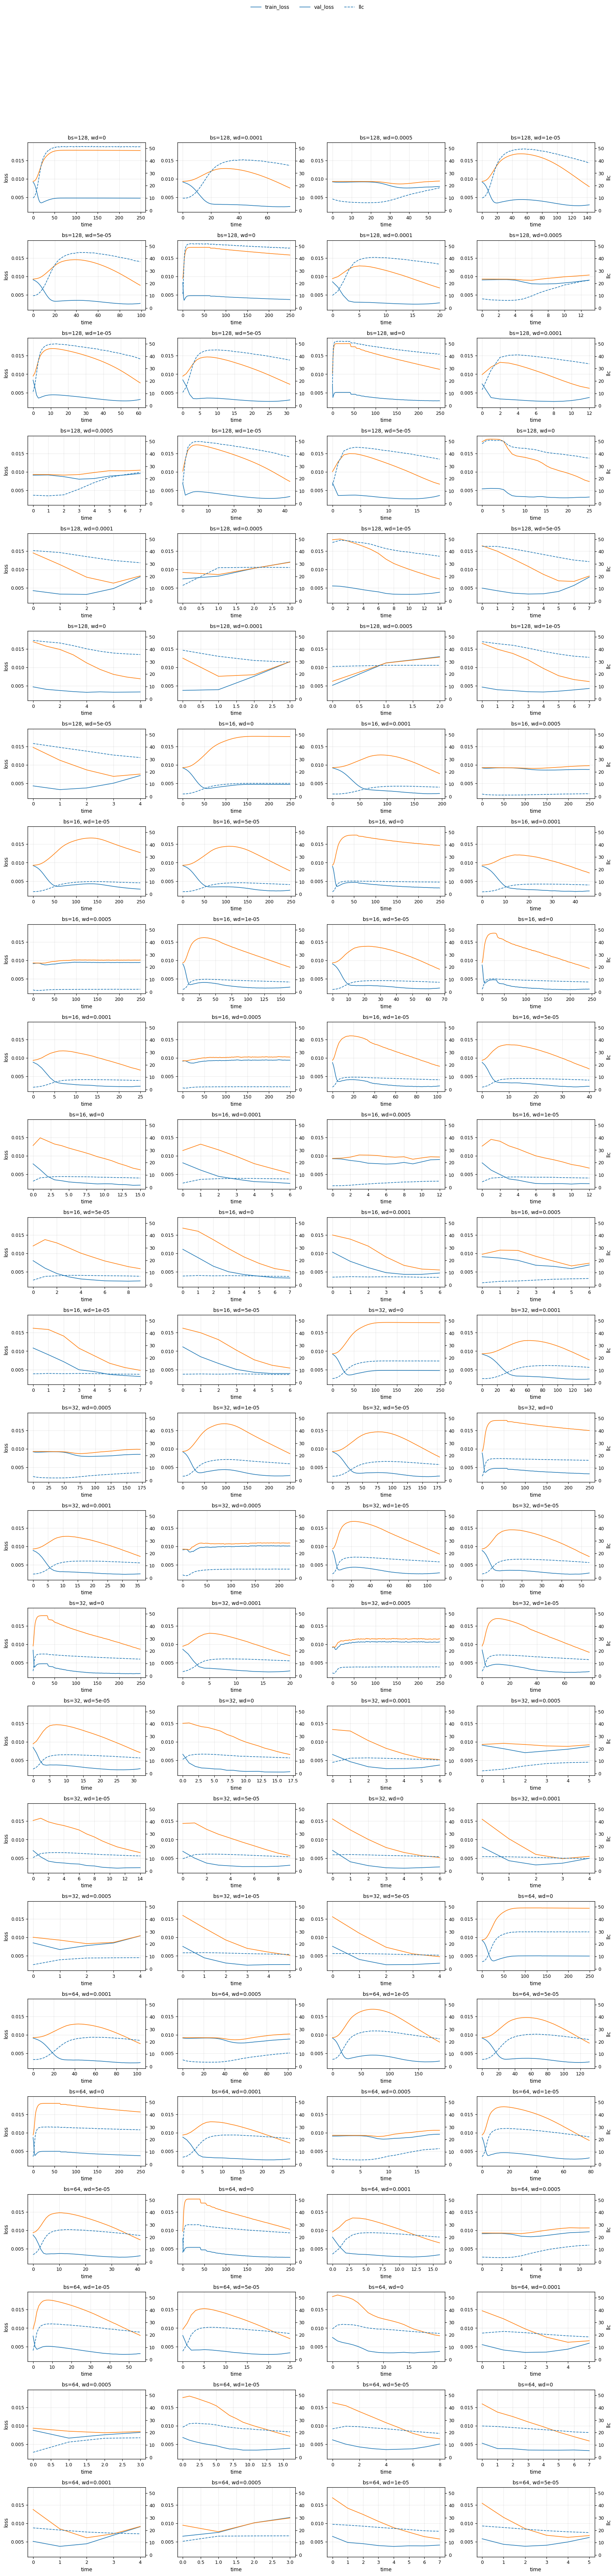

In [51]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.metrics import grokking_test3  # not used below, but keeping since you import it

root = "./results/sweep_batch_lr_wd"

# -----------------------------
# Load all runs first (so we can set global y-limits)
# -----------------------------
runs = []
for folder in sorted(os.listdir(root)):
    folder_path = os.path.join(root, folder)
    if not os.path.isdir(folder_path):
        continue

    params_path = os.path.join(folder_path, "params.csv")
    results_path = os.path.join(folder_path, "loss_data.csv")
    if not (os.path.exists(params_path) and os.path.exists(results_path)):
        continue

    params = pd.read_csv(params_path)
    results = pd.read_csv(results_path)

    # Required columns check
    required = {"train_loss", "val_loss", "llc"}
    if not required.issubset(results.columns):
        continue

    train_loss = results["train_loss"].to_numpy(dtype=float)
    val_loss   = results["val_loss"].to_numpy(dtype=float)
    llc        = results["llc"].to_numpy(dtype=float)

    # Optional: label each subplot with key params if present
    bs = params["batch_size"].values[0] if "batch_size" in params.columns else None
    wd = params["weight_decay"].values[0] if "weight_decay" in params.columns else None

    title_bits = []
    if bs is not None: title_bits.append(f"bs={int(bs)}")
    if wd is not None: title_bits.append(f"wd={wd:g}")
    title = ", ".join(title_bits) if title_bits else folder

    runs.append({
        "folder": folder,
        "title": title,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "llc": llc,
        "T": len(train_loss),
    })

if len(runs) == 0:
    raise RuntimeError(f"No valid runs found under {root} (missing CSVs or columns?).")

# Global y-limits so losses are on one scale (across all subplots)
all_losses = np.concatenate([np.r_[r["train_loss"], r["val_loss"]] for r in runs])
loss_min = np.nanmin(all_losses)
loss_max = np.nanmax(all_losses)
loss_pad = 0.05 * (loss_max - loss_min + 1e-12)
loss_ylim = (loss_min - loss_pad, loss_max + loss_pad)

# Global y-limits for LLC (across all subplots), on its own scale
all_llc = np.concatenate([r["llc"] for r in runs])
llc_min = np.nanmin(all_llc)
llc_max = np.nanmax(all_llc)
llc_pad = 0.05 * (llc_max - llc_min + 1e-12)
llc_ylim = (llc_min - llc_pad, llc_max + llc_pad)

# -----------------------------
# Grid size: "as big as possible" while staying readable
# Heuristic: use up to 4 columns; scale figure height by number of rows.
# -----------------------------
n = len(runs)
ncols = min(4, n)                 # 1..4 columns
nrows = math.ceil(n / ncols)

# Bigger figure; tweak these multipliers if you want even larger.
fig_w = 4.2 * ncols
fig_h = 2.8 * nrows
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharex=False)
axes = np.array(axes).reshape(-1)  # flatten even if nrows/ncols=1

# -----------------------------
# Plot
# -----------------------------
for i, (ax, r) in enumerate(zip(axes, runs)):
    t = np.arange(r["T"])

    # Left axis: losses
    ax.plot(t, r["train_loss"], linewidth=1.2, label="train_loss")
    ax.plot(t, r["val_loss"],   linewidth=1.2, label="val_loss")
    ax.set_ylim(*loss_ylim)
    ax.grid(True, alpha=0.25, linewidth=0.8)

    # Right axis: LLC
    ax2 = ax.twinx()
    ax2.plot(t, r["llc"], linewidth=1.2, linestyle="--", label="llc")
    ax2.set_ylim(*llc_ylim)

    ax.set_title(r["title"], fontsize=10)
    ax.set_xlabel("time")
    if i % ncols == 0:
        ax.set_ylabel("loss")
    if (i % ncols) == (ncols - 1) or (i == n - 1):
        ax2.set_ylabel("llc")

# Turn off unused axes
for j in range(len(runs), len(axes)):
    axes[j].axis("off")

# One global legend (cleaner than repeating on every subplot)
# Build handles from a dummy axis (matplotlib doesn't auto-merge twin axes legends nicely)
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], linewidth=1.2, label="train_loss"),
    Line2D([0],[0], linewidth=1.2, label="val_loss"),
    Line2D([0],[0], linewidth=1.2, linestyle="--", label="llc"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
path = "/home/se24/geom_phase_transitions/results/sweep_batch_lr_wd/run_batch_size=128_lr=0.0001_weight_decay=0.0001"
params = pd.read_csv(os.path.join(path, 'params.csv'))
results = pd.read_csv(os.path.join(path, 'loss_data.csv'))
train_loss = results['train_loss'].values
val_loss = results['val_loss'].values
llc = results['llc'].values


In [17]:
def plot_losses_and_llc(path: str = "/home/se24/geom_phase_transitions/results/sweep_batch_lr_wd/run_batch_size=128_lr=0.0001_weight_decay=0.0001",
                        type: str = "loss"):

    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    params = pd.read_csv(os.path.join(path, "params.csv"))
    results = pd.read_csv(os.path.join(path, "loss_data.csv"))

    if type == "loss":
        train_loss = results["train_loss"].to_numpy(dtype=float)
        val_loss   = results["val_loss"].to_numpy(dtype=float)
    elif type == "accuracy":
        train_loss = results["train_acc"].to_numpy(dtype=float)
        val_loss   = results["val_acc"].to_numpy(dtype=float)
    else:
        raise ValueError(f"Unknown type '{type}'; expected 'loss' or 'accuracy'.")
    llc        = results["llc"].to_numpy(dtype=float)

    T = len(train_loss)
    t = np.arange(T)*100

    # --------------------------------------------------
    # Plot styling (ICML-friendly)
    # --------------------------------------------------
    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })

    fig, ax = plt.subplots(figsize=(5.2, 3.4))

    # --------------------------------------------------
    # Left axis: losses
    # --------------------------------------------------
    line_train, = ax.plot(
        t, train_loss,
        linewidth=1.5,
        label="Training loss" if type == "loss" else "Training accuracy"
    )

    line_val, = ax.plot(
        t, val_loss,
        linewidth=1.5,
        label="Validation loss" if type == "loss" else "Validation accuracy"
    )

    ax.set_xlabel("Training epochs")
    ax.set_ylabel("Loss" if type == "loss" else "Accuracy")
    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.spines["top"].set_visible(False)

    # --------------------------------------------------
    # Right axis: LLC
    # --------------------------------------------------
    ax2 = ax.twinx()

    line_llc, = ax2.plot(
        t, llc,
        linewidth=1.5,
        linestyle="--",
        label="LLC", 
        color="tab:green"
    )

    ax2.set_ylabel("LLC")
    ax2.spines["top"].set_visible(False)

    # --------------------------------------------------
    # Title and legend
    # --------------------------------------------------
    # ax.set_title("Evolution of Losses and LLC During Training")

    ax.legend(
        handles=[line_train, line_val, line_llc],
        loc="best",
        frameon=False, 
        
    )

    fig.tight_layout()
    plt.show()


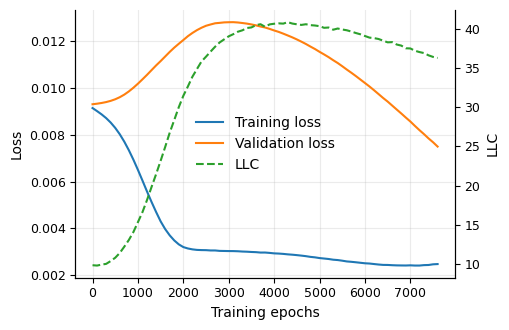

In [18]:
plot_losses_and_llc()

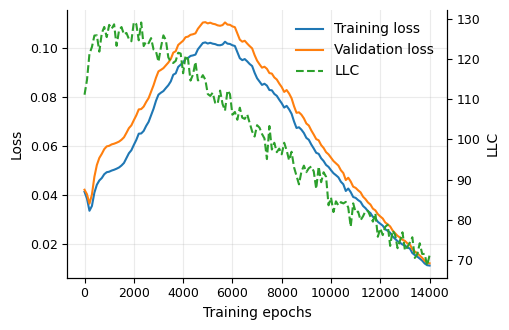

In [20]:
path = "/home/se24/geom_phase_transitions/results/run_transformer"
plot_losses_and_llc(path, type="loss")

# LLC curves for transformer models and LLMs

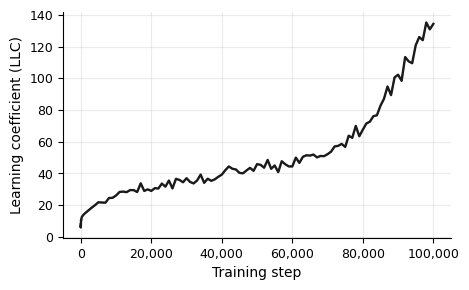

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Load Pythia LLC results
# --------------------------------------------------
path = "./results/EleutherAI/pythia-70m/llc_results.csv"

df = pd.read_csv(path)
df["step"] = (
    df["revision"]
      .astype(str)
      .str.replace("step", "", regex=False)
      .astype(int)
)

df = df.sort_values("step")
steps = df["step"].to_numpy()
llc = df["llc"].to_numpy()

# Optional light smoothing for presentation (5-point centered mean)
window = 5
llc_smooth = llc

# --------------------------------------------------
# Plot styling (ICML-friendly)
# --------------------------------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig, ax = plt.subplots(figsize=(4.8, 3.0))

ax.plot(
    steps,
    llc,
    color="#1b1b1b",
    linewidth=1.1,
    alpha=0.45
)

ax.plot(
    steps,
    llc_smooth,
    color="#1b1b1b",
    linewidth=1.7
)

ax.set_xlabel("Training step")
ax.set_ylabel("Learning coefficient (LLC)")

ax.grid(True, alpha=0.25, linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.tight_layout()
plt.show()


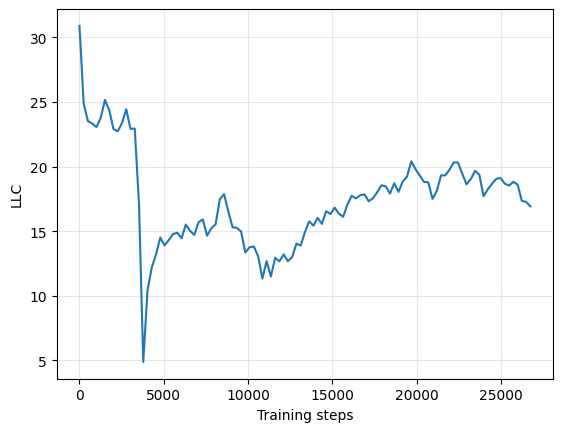

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data = pd.read_csv("/home/se24/geom_phase_transitions/results/sweep_transformer/transformer_test_dim_feedforward=256_embed_dim=256_lr=0.001_nhead=1_num_layers=2_weight_decay=1e-05/loss_data.csv")
llc = data['llc'].values
x = np.linspace(0, 250*(len(llc)), (len(llc)))
plt.plot(x,llc)
plt.xlabel("Training steps")
plt.ylabel("LLC")
plt.grid(alpha=0.3)